In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.pyplot import  cm

from scipy.signal import find_peaks
from statistics import mode

from scipy.interpolate import PchipInterpolator
from scipy import interpolate

from matplotlib.gridspec import GridSpec




<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:230: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:230: SyntaxWarning: invalid escape sequence '\m'
C:\Users\au617810\AppData\Local\Temp\ipykernel_6812\4202748695.py:100: SyntaxWarning: invalid escape sequence '\m'
  axFN.set_ylabel('Frequency noise [Hz$^\mathbf{2}$/Hz]', fontsize=fs, fontweight="bold",  labelpad = 2)
C:\Users\au617810\AppData\Local\Temp\ipykernel_6812\4202748695.py:230: SyntaxWarning: invalid escape sequence '\m'
  axFN.set_ylabel('Frequency noise [Hz$^\mathbf{2}$/Hz]', fontsize=fs, fontweight="bold",  labelpad = -2)


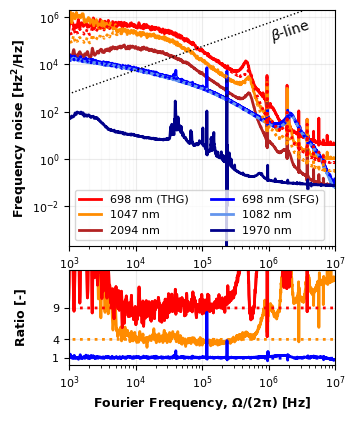

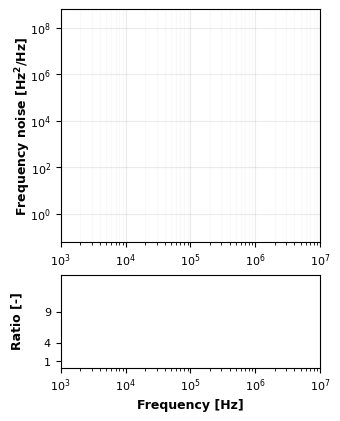

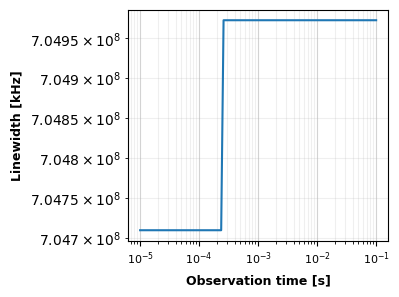

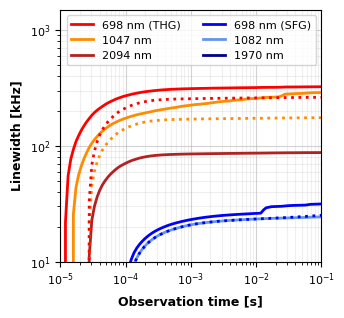

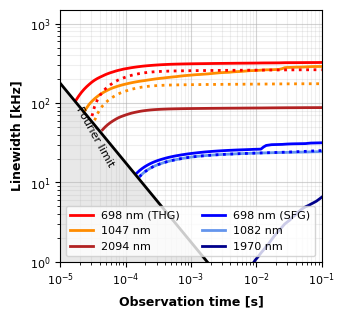

In [54]:

f_start = 1e3
f_end = 1e7

lw = 2

frequencies = np.logspace(np.log10(0.003), np.log10(3e7), int(1e5))
# frequencies = frequencies_raw[( (frequencies_raw>= f_start ) & (frequencies_raw<= f_end))]


folder = r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Frequency conversion RIN and FN\Pertoldi\plotting+data\plotting+data\\"
filename = 'THG FN spectra - New measurements.xlsx'
file_path = folder + filename

df698 = pd.read_excel(file_path,  sheet_name='698nm, 16.2m MZI')
freq698 = df698.iloc[:,0]
FN698 = df698.iloc[:, 5]
# Create an interpolation function
interp_func =  interpolate.interp1d(freq698, FN698, kind='linear', fill_value='extrapolate')#PchipInterpolator(freq698, FN698)
# Use this function to interpolate your data to match the new frequencies vector
FN698 = interp_func(frequencies)**2
 
df2095 = pd.read_excel(file_path,  sheet_name='2095nm, 10m MI') 
freq2095 = df2095.iloc[:,0]
FN2095 = df2095.iloc[:,-1]
# Create an interpolation function
interp_func =  interpolate.interp1d(freq2095, FN2095, kind='linear', fill_value='extrapolate')#PchipInterpolator(freq2095, FN2095)
# Use this function to interpolate your data to match the new frequencies vector
FN2095 = interp_func(frequencies)**2




filename = f'FN 1047 nm fit - 13'

data = pd.read_csv(folder + filename, sep = '\t' )

freq1047 = data['Frequency [Hz]']
FN1047 = data['Frequency noise [Hz/rt-Hz]']
# Create an interpolation function
interp_func =  interpolate.interp1d(freq1047, FN1047, kind='linear', fill_value='extrapolate')#PchipInterpolator(freq1047, FN1047)
# Use this function to interpolate your data to match the new frequencies vector
FN1047 = interp_func(frequencies)**2



# sfg data

# filename = '698nm SFG laser.xlsx'
# data = pd.read_excel(folder + filename, sheet_name= 'FN', skiprows=19)
# freq = data['Frequency'][1:]
# FN = data['FN'][1:]


filename = 'FN_SFG698_250mW1082_400mW1970.txt'

data = pd.read_csv(folder+filename, sep = '\t')

freq =  data.iloc[:,0 ]
fn = data.iloc[:,1:].to_numpy()
fnm = np.amax(fn, axis=1) 

# Create an interpolation function
interp_func =  interpolate.interp1d(freq, fnm, kind='linear', fill_value='extrapolate')#PchipInterpolator(freq , fnm)
# Use this function to interpolate your data to match the new frequencies vector
FN698SFG = interp_func(frequencies)**2

filename = '698nm SFG laser.xlsx'
data = pd.read_excel(folder + filename, sheet_name= 'FN', skiprows=19)
freq = data['Frequency.1'][1:]
FN = data['FN.1'][1:]
# Create an interpolation function
interp_func =  interpolate.interp1d(freq, FN, kind='linear', fill_value='extrapolate')#PchipInterpolator(freq , FN)
# Use this function to interpolate your data to match the new frequencies vector
FN1082 = interp_func(frequencies)**2


filename = '698nm SFG laser 2.xlsx'
data = pd.read_excel(folder + filename, sheet_name= 'FN (2)', skiprows=19)
freq = data['Frequency.2'][1:]
FN = data['FN.2'][1:]
# Create an interpolation function
interp_func =  interpolate.interp1d(freq, FN, kind='linear', fill_value='extrapolate')#PchipInterpolator(freq , FN)
# Use this function to interpolate your data to match the new frequencies vector
FN1970 = interp_func(frequencies)**2


# OLD 2095 FN

#%% 


# plt.close('all')

# plt.rcParams['text.usetex'] = True
fs, ls =  9, 8
figFN,  [axFN, axP]  = plt.subplots(2, 1, figsize=[ 3.35, 4.1  ], height_ratios=[5,  2])
 
axP.set_xlabel(r'Fourier Frequency, $\mathbf{\Omega/(2\pi)}$ [Hz]', fontsize=fs, fontweight="bold",  labelpad = 3)
axP.set_ylabel('Ratio [-]', fontsize=fs, fontweight="bold",  labelpad = 18)
axFN.set_ylabel('Frequency noise [Hz$^\mathbf{2}$/Hz]', fontsize=fs, fontweight="bold",  labelpad = 2)
axFN.xaxis.set_tick_params(labelsize=ls)
axFN.yaxis.set_tick_params(labelsize=ls)
axP.xaxis.set_tick_params(labelsize=ls)
axP.yaxis.set_tick_params(labelsize=ls)

axFN.grid(alpha = 0.25, which='major')
axFN.grid(alpha = 0.075, which='minor')
# axFN.minorticks_on()
axFN.xaxis.set_ticklabels([])
axP.yaxis.set_ticks([1, 4, 9])

axFN.set_yscale('log')
axFN.set_xscale('log')
axP.set_xscale('log')
# axP.set_yscale('log')

axP.set_xlim([1e3,10e6])
axP.set_ylim([0, 15 ])


axP.grid(alpha = 0.25, which='major')

axP.yaxis.set_ticks([1, 4, 9])
axFN.set_xlim([1e3,10e6])
axFN.set_ylim([0.214e-3,2e6])
    


# for ii in range(data.shape[1]-1):
#     fn = data.iloc[:,ii+1]
#     # axFN.plot(freq, fn)

# axFN.plot(freq, fnm, c = 'k')
 
axFN.plot(frequencies, FN698, c = 'r', ls = '-', lw = lw, label = '698 nm (THG)') 

axFN.plot(frequencies, FN1047, c = 'darkorange', ls = '-', lw = lw, label = '1047 nm') 
    
axFN.plot(frequencies, FN2095, c = 'firebrick', ls = '-', lw = lw, label = '2094 nm')
# axFN.plot(np.NaN, np.NaN, ls = 'none', marker = 'none', label = '  ')
# SFG
axFN.plot(frequencies, FN698SFG, c = 'blue', ls = '-', lw = lw, label = '698 nm (SFG)') 
axFN.plot(frequencies, FN1082, c = 'cornflowerblue', ls = '-', lw = lw, label  = '1082 nm')    
axFN.plot(frequencies, FN1970, c = 'darkblue', ls = '-', lw = lw, label = '1970 nm')  

axFN.plot(frequencies, FN1970 + FN1082, c = 'blue', ls = ':', lw = lw) 

axFN.plot(frequencies, FN2095*4, c = 'darkorange', ls = ':', lw = lw )
axFN.plot(frequencies, FN2095*9, c = 'red', ls = ':', lw = lw )

axP.plot(frequencies, FN1047/FN2095, c = 'darkorange', ls = '-', lw = lw, label = '1047 nm (THG)') 

axP.plot(frequencies, FN698/FN2095, c = 'r', ls = '-', lw = lw ) 
axP.plot(frequencies, 4*np.ones(len(frequencies)), c = 'darkorange', ls = ':', lw = lw ) 
axP.plot(frequencies, FN698/FN2095, c = 'r', ls = '-', lw = lw ) 
axP.plot(frequencies, 9*np.ones(len(frequencies)), c = 'r', ls = ':', lw = lw ) 

axP.plot(frequencies, FN698SFG/(FN1082 + FN1970),  c = 'b', ls = '-', lw = lw ) 

axP.plot(frequencies, 1*np.ones(len(frequencies)), c = 'blue', ls = ':', lw = lw ) 

axP.plot(frequencies, 4*4*np.ones(len(frequencies)), c = 'k', ls = ':', lw = lw ) 
axP.plot(frequencies, 25*9*np.ones(len(frequencies)), c = 'k', ls = ':', lw = lw ) 
 

axFN.text(1e6, 1e5, '$\\beta$-line',rotation = 18)

# folder = r'C:\Users\pertu\OneDrive - NKT Photonics\PhD\Birmingham secondment\experiments\laser characterization\SHG 1047\FN\\'
# s = 0
# for num in range(18):

#     filename = f'FN 1047 nm fit - {num:02d}'
    
#     data = pd.read_csv(folder + filename, sep = '\t' )
    
#     freq1047 = data['Frequency [Hz]']
#     FN1047 = data['Frequency noise [Hz/rt-Hz]']
#     if s == 0:
#         FNavg = np.zeros(len(FN1047))
#         s+= 1
        
#     # axFN.plot(freq1047, FN1047**2,  ls = '-', lw = lw, label = '1047 nm') 
#     FNavg += FN1047**2 
    
    

# folder = r'C:\Users\pertu\OneDrive - NKT Photonics\PhD\Laser\data\DORY2um\dory2 TmHo\2095 tests\frequency noise\\'
# filename = 'dory1+2'

# data = pd.read_csv(folder+filename, sep = '\t')

# freq =  data.iloc[:,0 ]
# for i in range(data.shape[1]):
#     fn = data.iloc[:,i].to_numpy()
#     axFN.plot(freq, fn**2 )




    

# axFN.plot(freq1047, FNavg/num, c = 'k',  ls = '-', lw = lw, label = '1047 nm') 


axFN.legend(fontsize = ls, ncol = 2 )

f = frequencies
beta_sqrt = np.sqrt(8*np.log(2) / (np.pi**2) *f )
beta = (8*np.log(2) / (np.pi**2) *f )

axFN.plot(f, beta, c='k', ls = ':', lw = 1)# , label = '$\\beta$-separation')
  
# 
# figFN.tight_layout()
figFN.subplots_adjust(left=0.175, right=0.97, top=0.99, bottom=0.125, hspace = 0.15)

savefolder = folder
figFN.savefig(savefolder + 'FN.pdf', dpi=300) 
#%% 




# plt.rcParams['text.usetex'] = True
fs, ls =  9, 8
figFN,  [axFN, axP]  = plt.subplots(2, 1, figsize=[ 3.35, 4.65  ], height_ratios=[5,  2])
 
axP.set_xlabel('Frequency [Hz]', fontsize=fs, fontweight="bold",  labelpad = 3)
axP.set_ylabel('Ratio [-]', fontsize=fs, fontweight="bold",  labelpad = 15)
axFN.set_ylabel('Frequency noise [Hz$^\mathbf{2}$/Hz]', fontsize=fs, fontweight="bold",  labelpad = -2)
axFN.xaxis.set_tick_params(labelsize=ls)
axFN.yaxis.set_tick_params(labelsize=ls)
axP.xaxis.set_tick_params(labelsize=ls)
axP.yaxis.set_tick_params(labelsize=ls)

axFN.grid(alpha = 0.25, which='major')
axFN.grid(alpha = 0.075, which='minor')
# axFN.minorticks_on()
axFN.xaxis.set_ticklabels([])
axP.yaxis.set_ticks([1, 4, 9])

axFN.set_yscale('log')
axFN.set_xscale('log')
axP.set_xscale('log')
# axP.set_yscale('log')

axP.set_xlim([1e3,10e6])
axP.set_ylim([0, 15 ])

axP.yaxis.set_ticks([1, 4, 9])
axFN.set_xlim([1e3,10e6])
axFN.set_ylim([0.6e-1,6e8])
    


# folder = r'C:\Users\pertu\OneDrive - NKT Photonics\PhD\AQuRA system\\'
# filename = '689nm SFG laser.xlsx'
# data = pd.read_excel(folder + filename, sheet_name= 'FN', skiprows=19)
# freq = data['Frequency.1'][1:]
# FN = data['FN.1'][1:]
# # Create an interpolation function
# interp_func = interpolate.interp1d(freq , FN, kind='linear', fill_value='extrapolate')
# # Use this function to interpolate your data to match the new frequencies vector
# FN1061 = interp_func(frequencies)**2

# axFN.plot(frequencies, FN1061, c = 'y', ls = '-', lw = lw, label  = '1082 nm')    






# folder = r'C:\Users\pertu\OneDrive - NKT Photonics\PhD\AQuRA system\\'
# filename = '1060nm laser.xlsx'
# data = pd.read_excel(folder + filename, sheet_name= 'FN', skiprows=1)
# freq = data['Frequency.2'][1:]
# FN = data['FN.2'][1:]
# # Create an interpolation function
# interp_func = interpolate.interp1d(freq , FN, kind='linear', fill_value='extrapolate')
# # Use this function to interpolate your data to match the new frequencies vector
# FN1061 = interp_func(frequencies)**2

# axFN.plot(frequencies, FN1061, c = 'purple', ls = '-', lw = lw, label  = '1082 nm')    

filename = '1060nm laser.xlsx'
data = pd.read_excel(folder + filename, sheet_name= 'FN', skiprows=1)
freq = data['Frequency.4'][1:]
FN = data['FN.4'][1:]
# Create an interpolation function
interp_func = PchipInterpolator(freq , FN)
# Use this function to interpolate your data to match the new frequencies vector
FN1061 = interp_func(frequencies)**2

# axFN.plot(frequencies, FN1061, c = 'g', ls = '-', lw = 2, label  = '1082 nm')    
# 


f = frequencies
beta  = 8*np.log(2) *f/ (np.pi**2)
 
ts = np.logspace(-5, -1, 100)
FN =  FN1061 # FNs[:, ii[0]]
count = 0 
lw = np.zeros(len(ts))
for t in ts: 
    fi = 1/t
# Create a mask based on the conditions

    mask = (FN >= beta) & (f >= fi)
    # Filter the arrays using the mask
    FN_filtered = FN[mask]
    f_filtered = f[mask]
    
    A = np.trapz(FN_filtered,f_filtered)
    
    lw[count]  = np.sqrt(8*np.log(2)*A) 
    
    count += 1 
    
fig  = plt.figure(figsize= [ 3.35, 3  ])
ax = fig.add_subplot(1,1,1)    

ax.set_xlabel('Observation time [s]', fontsize=fs, fontweight="bold",  labelpad = 5)
ax.set_ylabel('Linewidth [kHz]', fontsize=fs, fontweight="bold",  labelpad = 5)
ax.xaxis.set_tick_params(labelsize=ls)
ax.yaxis.set_tick_params(labelsize=ls)

ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_ylim([10 , 1.5e3])
# ax.set_xlim([1e-5 , 1e-1])

ax.grid(alpha = 0.55, which='major')
ax.grid(alpha = 0.2, which='minor')

ax.plot(ts, lw)

# folder = r'C:\Users\pertu\OneDrive\Andrea - NKT Photonics\PhD\waveguides\SFG module\\'

# filename = '689FNs.xlsx'
# file_path = folder + filename
# data = pd.read_excel(file_path)

# freq = data['Frequency']
# FN689 = data['FN 689']
# # FN698 = data['FN 698']
# FN1061 = data['FN 1061']
# # FN1082 = data['FN 1082']
# FN1970 = data['FN 1970']


# axFN.plot(freq, FN1061**2, c = 'k', ls = '-', lw = lw, label  = '1082 nm')    


#%% LINEWIDTHS 


ts = np.logspace(-5, -1, 100)
# ts = ts[::-1 ]
FNs = np.array([FN1082, FN1970, FN698SFG, FN2095, FN1047, FN698 ] )
FNs = FNs.T 

rows = len(FN1047)
# beta = (8*np.log(2) / (np.pi**2) *f ) 
liw = np.zeros(len(ts))
count = 0

lwdf = pd.DataFrame(np.zeros([len(ts), 6]), columns = ['liw_1082' , 'liw_1970' , 'liw_698SFG' , 'liw_2094' , 'liw_1047' ,  'liw_698THG' ])


 

f = frequencies
beta  = 8*np.log(2) * f / (np.pi**2)

for ii in enumerate(lwdf.columns):
    count = 0
    FN = FNs[:, ii[0]]
    lw = np.zeros(len(ts))
    for t in ts: 
        fi = 1/t
    # Create a mask based on the conditions
    
        mask = (FN >= beta) & (f >= fi)
        # Filter the arrays using the mask
        FN_filtered = FN[mask]
        f_filtered = f[mask]
        
        A = np.trapz(FN_filtered,f_filtered)
        
        lw[count]  = np.sqrt(8*np.log(2)*A)

        count += 1 

    
    lwdf[ii[1] ] = lw

#%% 
# plt.close('all')


fs = 9
ls = 8 

fig  = plt.figure(figsize= [ 3.35, 3  ])
ax = fig.add_subplot(1,1,1)    

ax.set_xlabel('Observation time [s]', fontsize=fs, fontweight="bold",  labelpad = 5)
ax.set_ylabel('Linewidth [kHz]', fontsize=fs, fontweight="bold",  labelpad = 5)
ax.xaxis.set_tick_params(labelsize=ls)
ax.yaxis.set_tick_params(labelsize=ls)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylim([10 , 1.5e3])
ax.set_xlim([1e-5 , 1e-1])

ax.grid(alpha = 0.55, which='major')
ax.grid(alpha = 0.2, which='minor')

 # columns = ['liw_1082' , 'liw_1970' , 'liw_698SFG' , 'liw_2094' , 'liw_1047' ,  'liw_698THG' ])
lw = 2

fourier_limit = (1.77) / ts / 1e3

# Function to plot lines above the Fourier limit
def plot_if_above_limit(ts, values, c, label = '', ls='-', lw=2):
    mask = values > fourier_limit  # Only plot where values are above the Fourier limit
    ax.plot(ts[mask], values[mask], c=c , ls=ls, lw=lw, label=label)
    
    
ax.plot(ts[:], lwdf['liw_698THG']/1e3, c  = 'r', ls = '-', lw = lw, label = '698 nm (THG)') 
ax.plot(ts[:], lwdf['liw_1047']/1e3, c = 'darkorange', ls = '-', lw = lw, label = '1047 nm') 
ax.plot(ts[:], lwdf['liw_2094']/1e3,c = 'firebrick', ls = '-', lw = lw, label = '2094 nm')


ax.plot(ts[:], lwdf['liw_698SFG']/1e3, c = 'blue', ls = '-', lw = lw, label = '698 nm (SFG)') 
ax.plot(ts[:], lwdf['liw_1082']/1e3, c = 'cornflowerblue', ls = '-', lw = lw, label  = '1082 nm')  
ax.plot(ts[:], lwdf['liw_1970']/1e3, c = 'darkblue', ls = '-', lw = lw, label = '1970 nm') 


 
ax.plot(ts[:], 2*lwdf['liw_2094']/1e3, c = 'darkorange', ls = ':', lw = lw ) 
ax.plot(ts[:], 3*lwdf['liw_2094']/1e3, c = 'r', ls = ':', lw = lw ) 
  
 
ax.plot(ts[:], np.sqrt(lwdf['liw_1970']**2 + lwdf['liw_1082']**2)/1e3, c = 'blue', ls = ':', lw = lw ) 

# ax.plot(ts,   (1.77)/ts /1e3 , c = 'k', lw = 2 label = 'Fourier limit', zorder = 1) 
 
# ax.fill_between(ts, (1.77) / ts / 1e3, color='lightgray' , alpha = 0.5  )
# ax.plot(ts,   (1.77)/ts /1e3 , c = 'k', lw = 2) #,  label = 'Fourier limit' ) 

# Add the label as text at a specific position (you can adjust x, y coordinates)
# ax.text(5, 0.3, 'Fourier limit', fontsize=12, color='black')
ax.legend(fontsize  = ls, ncol = 2)
  

fig.tight_layout() 

fig.subplots_adjust(left=0.17, right=0.95, top=0.99, bottom=0.15, hspace = 0)

fig.savefig(savefolder + 'LW.pdf', dpi=300) 



#%% 
# plt.close('all')


fs = 9
ls = 8 

fig  = plt.figure(figsize= [ 3.35, 3  ])
ax = fig.add_subplot(1,1,1)    

ax.set_xlabel('Observation time [s]', fontsize=fs, fontweight="bold",  labelpad = 5)
ax.set_ylabel('Linewidth [kHz]', fontsize=fs, fontweight="bold",  labelpad = 5)
ax.xaxis.set_tick_params(labelsize=ls)
ax.yaxis.set_tick_params(labelsize=ls)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylim([1 , 1.5e3])
ax.set_xlim([1e-5 , 1e-1])

ax.grid(alpha = 0.55, which='major')
ax.grid(alpha = 0.2, which='minor')

 # columns = ['liw_1082' , 'liw_1970' , 'liw_698SFG' , 'liw_2094' , 'liw_1047' ,  'liw_698THG' ])
lw = 2

fourier_limit = (1.77) / ts / 1e3

# Function to plot lines above the Fourier limit
def plot_if_above_limit(ts, values, c, label = '', ls='-', lw=2):
    mask = values > fourier_limit  # Only plot where values are above the Fourier limit
    ax.plot(ts[mask], values[mask], c=c , ls=ls, lw=lw, label=label)

    # ax.plot(ts, values, c=c , ls=ls, lw=lw, label=label)
    
    
plot_if_above_limit(ts[:], lwdf['liw_698THG']/1e3, c  = 'r', ls = '-', lw = lw, label = '698 nm (THG)') 
plot_if_above_limit(ts[:], lwdf['liw_1047']/1e3, c = 'darkorange', ls = '-', lw = lw, label = '1047 nm') 
plot_if_above_limit(ts[:], lwdf['liw_2094']/1e3,c = 'firebrick', ls = '-', lw = lw, label = '2094 nm')


plot_if_above_limit(ts[:], lwdf['liw_698SFG']/1e3, c = 'blue', ls = '-', lw = lw, label = '698 nm (SFG)') 
plot_if_above_limit(ts[:], lwdf['liw_1082']/1e3, c = 'cornflowerblue', ls = '-', lw = lw, label  = '1082 nm')  
plot_if_above_limit(ts[:], lwdf['liw_1970']/1e3, c = 'darkblue', ls = '-', lw = lw, label = '1970 nm') 


 
plot_if_above_limit(ts[:], 2*lwdf['liw_2094']/1e3, c = 'darkorange', ls = ':', lw = lw ) 
plot_if_above_limit(ts[:], 3*lwdf['liw_2094']/1e3, c = 'r', ls = ':', lw = lw ) 
  
 
plot_if_above_limit(ts[:], np.sqrt(lwdf['liw_1970']**2 + lwdf['liw_1082']**2)/1e3, c = 'blue', ls = ':', lw = lw ) 

# ax.plot(ts,   (1.77)/ts /1e3 , c = 'k', lw = 2 label = 'Fourier limit', zorder = 1) 
 
ax.fill_between(ts, (1.77) / ts / 1e3, color='lightgray' , alpha = 0.5  )
ax.plot(ts,   (1.77)/ts /1e3 , c = 'k', lw = 2) #,  label = 'Fourier limit' ) 

# Add the label as text at a specific position (you can adjust x, y coordinates)
# ax.text(5, 0.3, 'Fourier limit', fontsize=12, color='black')
ax.legend(fontsize  = ls, ncol = 2)

# Annotate "Fourier limit" parallel to the line
x_annotation = 1e-4  # Adjust this position as needed
y_annotation = (1.77) / x_annotation / 1e3

# Calculate the angle of the line (in degrees) for the annotation
angle = np.degrees(np.arctan2(-1, (1/x_annotation)))  # Slope of the line at that point
ax.annotate('Fourier limit', xy=(1e-5 , 16 ), xytext=(10, 0),
            textcoords='offset points', fontsize=ls, color='black', rotation= -61 )

fig.tight_layout()
fig.subplots_adjust(left=0.17, right=0.95, top=0.99, bottom=0.15, hspace = 0)


# savefolder = r'C:\Users\pertu\OneDrive - NKT Photonics\PhD\Laser\data\Conversion noise paper\autosave plots\\'
# fig.savefig(savefolder + 'LW.pdf', dpi=300) 




In [ ]:
np.where((ts-1e-2)>0)

(array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
        67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
        84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99],
       dtype=int64),)

In [56]:
ts[50]

0.001047615752789665

In [57]:
lwdf.loc[50]

liw_1082       20925.253729
liw_1970           0.000000
liw_698SFG     23231.715531
liw_2094       85280.371954
liw_1047      225644.973744
liw_698THG    312555.909857
Name: 50, dtype: float64

In [58]:
np.where((ts-1e-2)>0)

(array([75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91,
        92, 93, 94, 95, 96, 97, 98, 99], dtype=int64),)

In [60]:
lwdf.loc[75]

liw_1082       23417.963489
liw_1970        1162.747993
liw_698SFG     26192.026307
liw_2094       86646.292972
liw_1047      258350.517809
liw_698THG    319395.136430
Name: 75, dtype: float64

In [ ]:
lwdf.loc[50] ##sqrt(beta)

liw_1082       43088.271713
liw_1970       18650.241933
liw_698SFG     46785.910972
liw_2094      112644.251463
liw_1047      254370.313167
liw_698THG    364026.442569
Name: 50, dtype: float64